<a href="https://colab.research.google.com/github/kangJagoCoding/GetNotes/blob/main/TUGAS_DATASCI_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Dataset_Transaksi_Inferensial.csv')
print("=== 5 baris pertama ==="+"="*50)
print(df.head())
print("\n"+"="*70+ "\n")

=== 5 baris pertama =====================================================
   ID_Transaksi Warna_Tombol   Metode_Bayar  Waktu_Akses_Menit  \
0             1         Biru       E-Wallet                5.2   
1             2        Hijau  Transfer Bank               12.5   
2             3         Biru   Kartu Kredit                3.1   
3             4        Hijau       E-Wallet                8.0   
4             5         Biru       E-Wallet                4.5   

   Nominal_Transaksi  
0             150000  
1             250000  
2             350000  
3             175000  
4             120000  




In [ ]:
print("\n"+"="*60+ "\n")
grop_biru = df[df['Warna_Tombol']=='Biru']['Nominal_Transaksi']
grop_hijau = df[df['Warna_Tombol']=='Hijau']['Nominal_Transaksi']

t_stat, p_value = stats.ttest_ind(grop_biru, grop_hijau)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Tolak H0. terdapat perbedaan")
else:
    print("Gagal Tolak H0. tidak ada perbedaan signifikat")
print("\n"+"="*60+ "\n")



T-statistic: -1.3227
P-value: 0.2025
Gagal Tolak H0. tidak ada perbedaan signifikat




In [ ]:
print("\n"+"="*60+ "\n")
ewallet = df[df['Metode_Bayar']=='E-Wallet']['Nominal_Transaksi']
transfer = df[df['Metode_Bayar']=='Transfer Bank']['Nominal_Transaksi']
kredit = df[df['Metode_Bayar']=='Kartu Kredit']['Nominal_Transaksi']

f_stat,p_val_anova = stats.f_oneway(ewallet, transfer, kredit)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value_anova: {p_val_anova:.4f}")

if p_val_anova < 0.05:
  print("Kesimpulan: Tolak H0. ada perbedaan rata-rata transaksi yang signifikat")
else:
  print("Kesimpulan: Gagal Tolak H0. Tidak ada perbedaan signifikat")
print("\n"+"="*60+ "\n")



F-statistic: 76.7215
P-value_anova: 0.0000
Kesimpulan: Tolak H0. ada perbedaan rata-rata transaksi yang signifikat




Korelasi r: 0.5556
P-value_corr: 0.0110


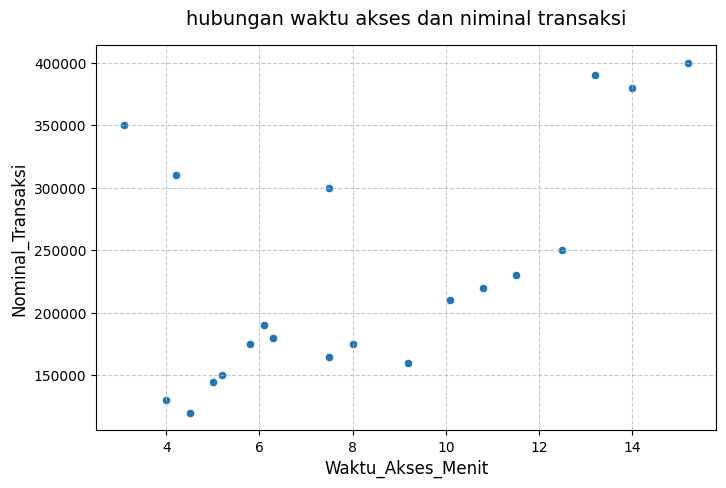

In [ ]:
korelasi, p_val_corr = stats.pearsonr(df['Waktu_Akses_Menit'], df['Nominal_Transaksi'])
print(f"Korelasi r: {korelasi:.4f}")
print(f"P-value_corr: {p_val_corr:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Waktu_Akses_Menit', y='Nominal_Transaksi', data=df)
plt.title('hubungan waktu akses dan niminal transaksi', fontsize=14, pad=15)
plt.xlabel('Waktu_Akses_Menit', fontsize=12)
plt.ylabel('Nominal_Transaksi', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()